# Gym Membership Churn Analysis

## Table of Contents

- [Introduction](#Introduction)
- [Business Context and Goals](#Business-Context-and-Goals)
- [Notebook Structure](#Notebook-Structure)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Cohort Analysis](#Cohort-Analysis)
- [Building a Predictive Model](#link)
- [Feature Importance](#Feature-Importance)
- [Catching 80% of Churners](#Decision-Thresholds)
- [Building Churn Risk Tiers and Personas](#link)
- [Making Predictions in Practice](#link)
- [Business Insights and Recommendations](#Business-Insights-and-Recommendations)

## Introduction

This notebook explores gym member churn — when and why members cancel their memberships. We analyze demographic, behavioral and contract data to understand patterns and build a model that predicts churn risk.

### Key Takeaways
- Achieved **97% ROC-AUC** with **92% precision** at **80% recall** using a Random Forest model.
- Calibrated decision threshold to trade off between false alarms and true positives.
- Defined **actionable personas** (e.g., "Drifting") based on risk tiers.
- Found **contract timing** and **low attendance** to be key churn indicators.
- Packaged model to return **churn probability**, **risk tier**, and **yes/no flag** for every user.


## Business Context and Goals

Churn is a major cost driver in subscription-based businesses like gyms. Members who cancel early reduce customer lifetime value and may be preventable with timely intervention.

The goals of this project are to:
- Understand the key drivers of churn
- Identify high-risk members based on their behavior and profile
- Support business actions like targeted outreach or contract changes

We use descriptive statistics, cohort analysis, and machine learning to explore the problem from both business and modeling perspectives.


## Notebook Structure

- **Exploratory Data Analysis:** Examine churn rates across categorical features and compare numeric distributions by churn group. Use t-tests to evaluate whether differences in feature means (e.g., age, class frequency) between churners and non-churners are statistically significant.
- **Cohort Analysis:** Segment members into cohorts by time since joining. Compare churn rates, engagement, and contract types across cohorts. Test whether cohorts differ significantly on key features.
- **Building a Predictive Model:** Train a Random Forest model to predict churn. Evaluate performance with PR-AUC and ROC-AUC.
- **Feature Importance:** Use two different methods to identify the most important features influencing churn predictions.
- **Catching 80% of Churners** Use the precision-recall curve to identify probability thresholds that detect high proportions of churners while controlling false positives.
- **Building Churn Risk Tiers and Personas:** Convert churn probabilities into four risk groups (Low, Medium, High, Very High). Describe typical characteristics of each group.
- **Making Predictions in Practice:** Briefly demonstrate how the model can be applied to a new member’s data. Outline what's needed to deploy this in practice.
- **Business Insights and Recommendations:** Summarize findings and propose actionable next steps based on the analysis.

# Exploratory Data Analysis

In this section, we get to know the data and run some tests to see what kind of variables we have.

**Data Columns:** The dataset contains churn information for the **current month** and member data for the **previous month**.

- Churn - Cancellation for the current month.
- Gender - The user's gender (0 or 1, not clear which is male and female).
- Near_Location - If the user lives or works in the neighborhood where the gym is located.
- Partner - If the user works in an associated company (the gym has associated companies whose employees get discounts; in those cases, the gym stores information about the clients' employers).
- Promo_friends - If the user originally signed up through a "bring a friend" offer (they used a friend's promotional code when they paid the first subscription).
- Phone - If the user provided their phone number.
- Contract_period - The customer's contract period in months.
- Group_visits - Whether the customer's membership allows to bring friends.
- Age - The customer's age.
- Avg_additional_charges_total - Additional charges on the customer's account.
- Month_to_end_contract - Months until the current contract ends.
- Lifetime - The time (in months) since the user first arrived at the gym.
- Avg_class_frequency_total - Average number of classes the customer attended (not clear from data if this is per week, per month, or other).
- Avg_class_frequency_current_month - Average number of classes the customer attended in the current month.

**Findings in this section**

- Data has no missing values
- Gender and Phone variables do not seem to affect churn.
- Members are less likely to churn if they live closer to the gym, work at an associated company, signed up through the friend promo, have a longer contract period, and/or are allowed to bring friends.
- Churners also tend to be younger and attend less classes.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from minieda import summarize # to install this package, run `pip install git+https://github.com/dbolotov/minieda.git`
from scipy.stats import ttest_ind, t

import time
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.inspection import permutation_importance

pd.set_option("display.precision", 2)

In [2]:
df = pd.read_csv("gym_churn_us.csv")
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0


In [3]:
# Show summary statistics for the dataset
summarize(df)

,dtype,count,unique,unique_perc,missing,missing_perc,zero,zero_perc,mean,std,min,50%,max,skew
gender,int64,4000,2,0.05,0,0.0,1959,48.98,0.51,0.50,0.00,1.00,1.00,-0.04
Near_Location,int64,4000,2,0.05,0,0.0,619,15.48,0.85,0.36,0.00,1.00,1.00,-1.91
Partner,int64,4000,2,0.05,0,0.0,2053,51.32,0.49,0.50,0.00,0.00,1.00,0.05
Promo_friends,int64,4000,2,0.05,0,0.0,2766,69.15,0.31,0.46,0.00,0.00,1.00,0.83
Phone,int64,4000,2,0.05,0,0.0,386,9.65,0.90,0.30,0.00,1.00,1.00,-2.73
Contract_period,int64,4000,3,0.08,0,0.0,0,0.00,4.68,4.55,1.00,1.00,12.00,0.71
Group_visits,int64,4000,2,0.05,0,0.0,2351,58.78,0.41,0.49,0.00,0.00,1.00,0.36
Age,int64,4000,23,0.57,0,0.0,0,0.00,29.18,3.26,18.00,29.00,41.00,-0.06
Avg_additional_charges_total,float64,4000,4000,100.00,0,0.0,0,0.00,146.94,96.36,0.15,136.22,552.59,0.62
Month_to_end_contract,float64,4000,12,0.30,0,0.0,0,0.00,4.32,4.19,1.00,1.00,12.00,0.81


In [4]:
# Create lists of categorical and numerical variables
cat_vars = ["gender", "Near_Location", "Partner",  "Promo_friends", "Phone", "Contract_period", "Group_visits"]
num_vars = ["Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]

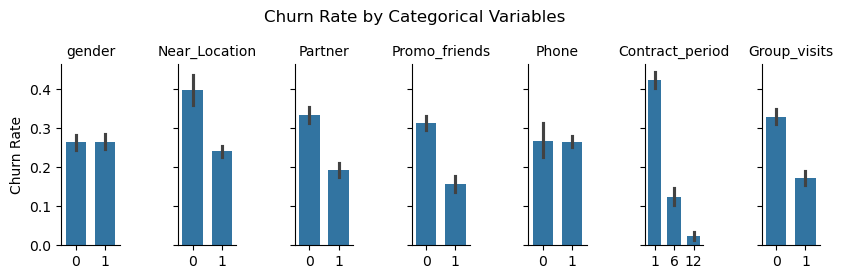

In [5]:
# Plot churn rate for categorical variables, split by categories

g = sns.FacetGrid(
    pd.melt(df, id_vars="Churn", value_vars=cat_vars),
    col="variable", col_wrap=7, sharey=True, sharex=False, height=3, aspect=0.4)
g.map_dataframe(sns.barplot, x="value", y="Churn", estimator=lambda x: sum(x)/len(x), width=0.7)
g.set_axis_labels("", "Churn Rate")
g.set_titles("{col_name}")
g.fig.suptitle("Churn Rate by Categorical Variables")
g.fig.subplots_adjust(top=0.8, wspace = 1)  # adjust to fit the title

plt.show()

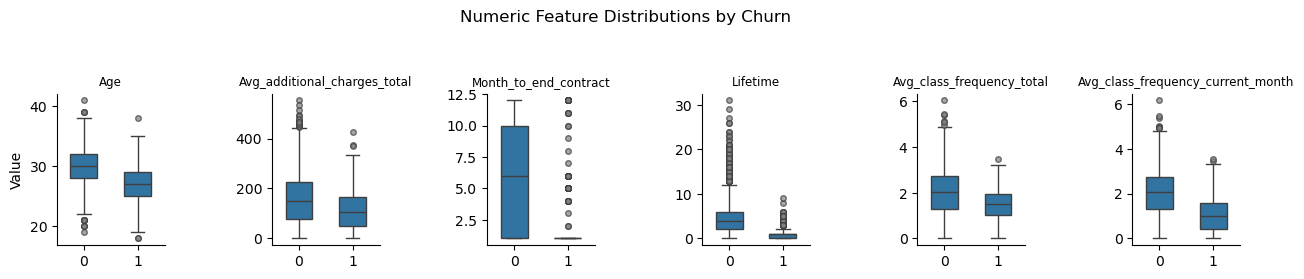

In [7]:
# Create boxplots for numeric features by churn

df_plot = df.copy()

melted = pd.melt(df_plot, id_vars="Churn", value_vars=num_vars)

g = sns.FacetGrid(melted, col="variable", sharey=False, height=3, aspect=0.7)
g.map_dataframe(sns.boxplot, x="Churn", y="value", showfliers=True, 
                flierprops=dict(marker='o', markersize=4, markerfacecolor="gray", alpha=0.7),
                width=0.5)

g.set_titles("{col_name}", size=8.5)
g.set_axis_labels("", "Value")

g.fig.suptitle("Numeric Feature Distributions by Churn")
g.fig.subplots_adjust(top=0.7, wspace = 1)

plt.show()

In [9]:
import numpy as np
import pandas as pd


def run_ttests_with_means(df, num_vars, churn_col="Churn", pretty=False):
    """
    Compare numeric variables between churners (1) and non-churners (0).
    Uses Welch's t-test (unequal variances), and reports:
      - group means
      - mean difference (churners - non-churners)
      - t-statistic, p-value
      - 95% CI for the mean difference (Welch)
      - Hedges' g (effect size, small-sample corrected)

    Params
    ------
    df : DataFrame
    num_vars : list[str]
    churn_col : str (default "Churn")
    pretty : bool -> if True, returns a formatted table (strings)

    Returns
    -------
    DataFrame
    """
    rows = []

    for var in num_vars:
        g1 = df[df[churn_col] == 1][var].dropna()  # churners
        g0 = df[df[churn_col] == 0][var].dropna()  # non-churners

        n1, n0 = len(g1), len(g0)
        m1, m0 = g1.mean(), g0.mean()
        s1, s0 = g1.std(ddof=1), g0.std(ddof=1)

        # Welch t-test
        t_stat, p_val = ttest_ind(g1, g0, equal_var=False)

        # Mean difference and its SE (Welch)
        diff = m1 - m0
        se = np.sqrt((s1**2 / n1) + (s0**2 / n0))

        # Welch-Satterthwaite degrees of freedom
        df_welch_num = (s1**2 / n1 + s0**2 / n0) ** 2
        df_welch_den = ((s1**2 / n1) ** 2) / (n1 - 1) + ((s0**2 / n0) ** 2) / (n0 - 1)
        dof = df_welch_num / df_welch_den

        # 95% CI for mean difference
        t_crit = t.ppf(0.975, dof)
        ci_low = diff - t_crit * se
        ci_high = diff + t_crit * se

        # Effect size: Hedges' g (using pooled SD, then small-sample correction)
        sp2 = ((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2)
        sp = np.sqrt(sp2)
        d = diff / sp if sp > 0 else np.nan
        J = 1 - (3 / (4*(n1 + n0) - 9))  # small sample correction
        g_hedges = d * J

        rows.append({
            "Variable": var,
            "n_churn": n1, "mean_churn": m1,
            "n_non": n0, "mean_non": m0,
            "diff_mean": diff,
            "t_stat": t_stat, "p_value": p_val,
            "ci_low": ci_low, "ci_high": ci_high,
            "hedges_g": g_hedges
        })

    out = pd.DataFrame(rows).sort_values("p_value")

    if not pretty:
        return out.reset_index(drop=True)

    # Formatting
    out_fmt = out.copy()
    out_fmt["mean_churn"] = out_fmt["mean_churn"].map(lambda x: f"{x:.3f}")
    out_fmt["mean_non"]   = out_fmt["mean_non"].map(lambda x: f"{x:.3f}")
    out_fmt["diff_mean"]  = out_fmt["diff_mean"].map(lambda x: f"{x:+.3f}")
    out_fmt["t_stat"]     = out_fmt["t_stat"].map(lambda x: f"{x:.3f}")
    out_fmt["p_value"]    = out_fmt["p_value"].map(lambda x: f"{x:.3e}")
    out_fmt["ci"]         = out.apply(lambda r: f"[{r.ci_low:.3f}, {r.ci_high:.3f}]", axis=1)
    out_fmt["hedges_g"]   = out_fmt["hedges_g"].map(lambda x: f"{x:+.3f}")

    cols = ["Variable", "mean_churn", "mean_non",
            "diff_mean", "t_stat", "p_value", "ci", "hedges_g"]
    return out_fmt[cols].reset_index(drop=True)

results = run_ttests_with_means(df, num_vars, pretty=True)
results

,Variable,mean_churn,mean_non,diff_mean,t_stat,p_value,ci,hedges_g
0,Lifetime,0.991,4.712,-3.721,-46.990,0.000e+00,"[-3.876, -3.566]",-1.104
1,Month_to_end_contract,1.663,5.283,-3.621,-35.996,1.285e-244,"[-3.818, -3.423]",-0.934
2,Avg_class_frequency_current_month,1.045,2.028,-0.983,-32.553,1.049e-193,"[-1.043, -0.924]",-1.025
3,Age,26.990,29.977,-2.987,-28.501,1.438e-149,"[-3.192, -2.781]",-1.002
4,Avg_class_frequency_total,1.475,2.025,-0.550,-19.368,2.011e-78,"[-0.606, -0.494]",-0.584
5,Avg_additional_charges_total,115.083,158.446,-43.363,-14.391,4.230e-45,"[-49.271, -37.454]",-0.459


# Cohort Analysis

Find groups of people that started around the same time and see how their churn patterns evolve.

Bin customers into 4 cohorts - New (<3 months), Early (3-5 months), Established (6-11 months), Loyal (12+ months).

In [10]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0


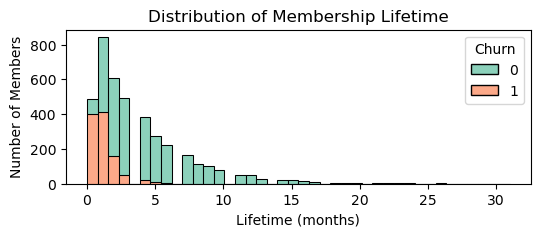

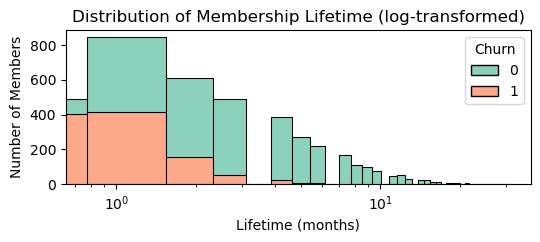

In [11]:
# Show distribution of Lifetime and separate by Churn
plt.figure(figsize=(6,2))

sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")

plt.title("Distribution of Membership Lifetime")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

plt.figure(figsize=(6,2))
sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")
plt.xscale("log")
plt.title("Distribution of Membership Lifetime (log-transformed)")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

In [12]:
# Separate data into cohorts based on Lifetime:

df_cohort = df.copy(deep=True)

df_cohort["Cohort"] = pd.cut(x=df_cohort["Lifetime"], bins=[0, 3, 6, 12, np.inf], right=False,
                             labels=["New", "Early", "Established", "Loyal"], retbins=False,
                             precision=3, include_lowest=True, duplicates='raise', ordered=True)

In [13]:
df_cohort

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,Cohort
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0,Early
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0,Established
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0,New
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0,New
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0,Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0,Established
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1,New
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0,New
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0,Early


In [14]:
# Create summary with member counts, and means of numerical variables by cohort
df_c_summary = (df_cohort.groupby("Cohort", observed=False)
                .agg(Member_Count=("Churn", "size"),
                     Member_Perc=("Churn", lambda x: len(x) / len(df_cohort)),
                     Churn_Perc=("Churn", "mean"),
                     Age_mean=("Age", "mean"),
                     Avg_addl_charges_tot_mean =("Avg_additional_charges_total", "mean"),
                     Avg_class_f_tot_mean=("Avg_class_frequency_total", "mean"),
                     Avg_class_f_cm_mean=("Avg_class_frequency_current_month", "mean")))

df_c_summary["Member_Perc"] = (df_c_summary["Member_Perc"] * 100)
df_c_summary["Churn_Perc"]  = (df_c_summary["Churn_Perc"] * 100)

df_c_summary

,Member_Count,Member_Perc,Churn_Perc,Age_mean,Avg_addl_charges_tot_mean,Avg_class_f_tot_mean,Avg_class_f_cm_mean
Cohort,,,,,,,
New,1940,48.50,50.21,28.47,137.53,1.73,1.52
Early,1146,28.65,7.07,29.79,156.29,2.01,1.98
Established,722,18.05,0.83,30.00,153.78,2.03,2.02
Loyal,192,4.80,0.00,29.68,160.56,2.01,2.02


Average class frequency total - Churners tend to leave early, and those who stay quickly settle into a routine of about 2 visits per week. Past 6 months, engagement stabilizes, suggesting that keeping members engaged through the first 3 months is critical.

Age - mean age is around 28-30 years old - not a large gap.


In [15]:
# Show contingency table of Cohort and Contract_period
pd.crosstab(df_cohort["Cohort"], df_cohort["Contract_period"], normalize="index").map(lambda x: f"{x:.0%}")

Contract_period,1,6,12
Cohort,,,
New,65%,18%,17%
Early,46%,24%,29%
Established,44%,23%,33%
Loyal,48%,22%,30%


The above table shows that among new members, 65% are on a 1-month contract. Among Loyal members (12+ months attendance), almost half (48%) are on 1-month contract. If monthly cost difference between 1- and 12-month contracts is small, members might not bother to switch. A potential action here is to target loyal month-to-month members with offers to switch to a discounted 12-month plan. Even if churn is already low, locking them in creates more predictable revenue.

## Building a Predictive Model
Train and evaluate a Random Forest model to predict whether a customer churns in the current month given data for the past month.

We split the data into train and test sets. The train set is further split up during grid search for the best model params.

We pre-process the data by scaling numeric variables and one-hot encoding categorical variables, and then run a grid search to find the best parameters for a random forest model, optimizing for average precision.

**Why use average precision during grid search?**
- Optimizing average precision finds parameters which will work with different thresholds. We can then change the decision threshold to tailor the model to specific business use cases. Optimizing a specific metric (like F1 score or Recall) trains the model for that specific metric only.

In [16]:
# Print value counts (normalized and raw)
print(df['Churn'].value_counts(normalize=True))
print(df['Churn'].value_counts(normalize=False))

Churn
0    0.73
1    0.27
Name: proportion, dtype: float64
Churn
0    2939
1    1061
Name: count, dtype: int64


The data is imbalanced - only 27% of observations represent customers that churned.

In [17]:
# Split the data
X = df[cat_vars + num_vars]
y = df['Churn']

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define preprocessing for numeric and categorical features
numeric_preprocessing = Pipeline([
    ('scale', StandardScaler())
])

categorical_preprocessing = Pipeline([
    ('encode', OneHotEncoder(drop='first', sparse_output=False))  # one-hot; drop first feature to avoid multicollinearity
])

# Combine into a column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_preprocessing, num_vars),
    ('cat', categorical_preprocessing, cat_vars)
])

In [18]:
# Grid search

# Base pipeline
clf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'model__n_estimators': [40,100,200],
    'model__max_depth': [None],
    'model__min_samples_leaf': [1, 3, 5, 7],
    'model__max_features': ['sqrt']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

# Fit grid search on training data
print("Running Grid Search...")
start_time = time.time()
grid_search.fit(X_train, y_train)
print(f"\nGrid search completed in {time.time() - start_time:.2f} seconds")

Running Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid search completed in 9.75 seconds


In [19]:
print("Best Grid Search Result:\n")
print(f"Average Precision: {grid_search.best_score_:.4f} ± {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")
print("Parameters:")
pprint(grid_search.best_params_)

Best Grid Search Result:

Average Precision: 0.9248 ± 0.0078
Parameters:
{'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 3,
 'model__n_estimators': 100}


## Model Evaluation

We compute PR-AUC and ROC-AUC, as well as plot the Precision-Recall Curve.

The best model reaches a PR-AUC of 0.93, compared to a baseline of 0.27 (the churn rate in the test set). This means the model is much better than random guessing at ranking members by churn risk. It also achieves a ROC-AUC of 0.97 (baseline = 0.50), showing it can reliably separate churners from non-churners overall.

Because churn is relatively rare (about 27% of members), PR-AUC is the more meaningful measure. It shows how well the model balances catching churners (recall) with avoiding false alarms (precision) across all possible decision thresholds.

Model PR-AUC: 0.930 (baseline = 0.265)
Model ROC-AUC: 0.967 (baseline = 0.500)


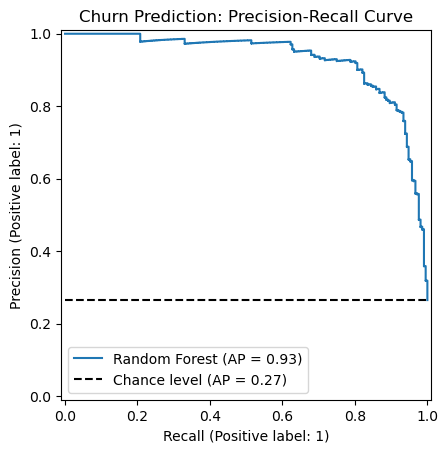

In [20]:
# Use best model from grid search
clf_pipeline = grid_search.best_estimator_

# Get probabilities for Churn = 1
y_test_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print(f"Model PR-AUC: {average_precision_score(y_test, y_test_pred_proba):.3f} (baseline = {y_test.mean():.3f})")
print(f"Model ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.3f} (baseline = 0.500)")

# Plot PR curve
display = PrecisionRecallDisplay.from_estimator(clf_pipeline, X_test, y_test, name="Random Forest",
                                                plot_chance_level=True, despine=False)
_ = display.ax_.set_title("Churn Prediction: Precision-Recall Curve")

## Feature Importance

To understand what drives churn predictions, we look at feature importance. This tells us which inputs the model relies on most when making decisions. We use two complementary approaches:

- **Random Forest built-in importance**: looks at how often and how strongly a feature is used to split the data inside the trees.
- **Permutation importance**: tests the trained model by shuffling each feature and seeing how much performance drops. This is often more reliable, because it measures impact on actual predictions.

Both methods give a ranking of features, helping us see which factors matter most.

Running the analysis, we see that the top drivers of churn are consistent across both approaches: Lifetime, recent class frequency and overall class frequency, age, and month to end contract. Other features such as referral promotions, group visits, or other demographics (gender, location, phone flag) add little value.

**Takeaway:** engagement behaviors (attendance) and tenure/contract features dominate the model, while demographics do not. This means retention actions should focus on usage and membership design, not personal characteristics.

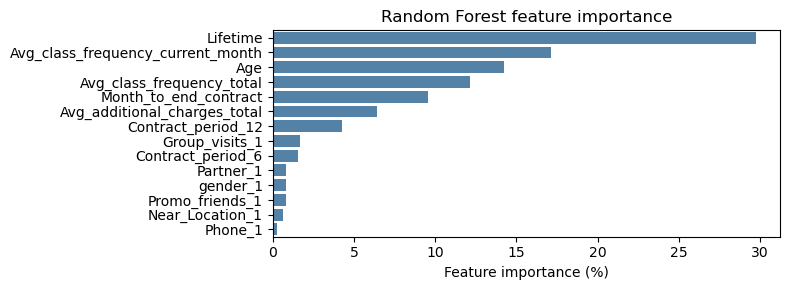

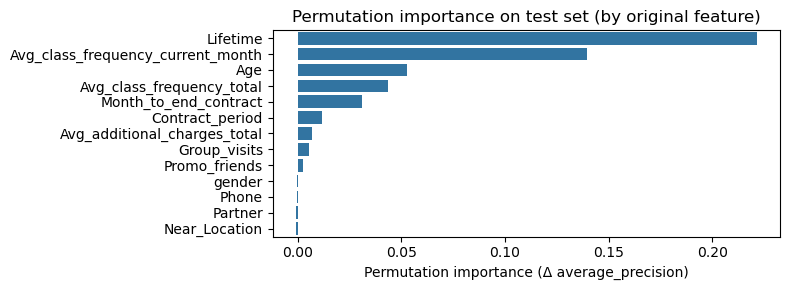

In [21]:
# Feature importance using the RF model itself
model = clf_pipeline.named_steps["model"]
feature_names = clf_pipeline.named_steps["pre"].get_feature_names_out()

# Clean feature names for readability
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

fi = (pd.DataFrame({"feature": clean_names, "importance": model.feature_importances_})
      .sort_values("importance", ascending=False))

# Normalize to percent
fi["importance_pct"] = 100 * fi["importance"] / fi["importance"].sum()

plt.figure(figsize=(8, 3))
sns.barplot(data=fi, y="feature", x="importance_pct", color="steelblue")
plt.xlabel("Feature importance (%)")
plt.ylabel("")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

# Permutation importance on the full pipeline and original inputs
r = permutation_importance(
    clf_pipeline, X_test, y_test,
    scoring="average_precision",
    n_repeats=10, random_state=42, n_jobs=-1
)

#Use original column names (one per input feature)
orig_feature_names = list(X_test.columns)

pi = (pd.DataFrame({
        "feature": orig_feature_names,
        "mean_importance": r.importances_mean,
        "std": r.importances_std
     }).sort_values("mean_importance", ascending=False))

# Plot features
plt.figure(figsize=(8,3))
sns.barplot(data=pi, y="feature", x="mean_importance")
plt.xlabel("Permutation importance (Δ average_precision)")
plt.ylabel("")
plt.title("Permutation importance on test set (by original feature)")
plt.tight_layout()
plt.show()

## Catching 80% of Churners

To meet a key business goal — identifying at least 80% of members likely to churn — we use the precision–recall curve to select an appropriate probability threshold. This threshold determines whether a predicted churn probability is labeled as "churn" (1) or "not churn" (0). In this approach, any member with a predicted probability equal to or over the threshold is flagged for churn intervention.

This allows us to align the model's outputs with real-world business needs: maximizing recall while keeping false positives manageable.

Applying the 80% recall rule yields:

- Threshold = 0.519 (just above the standard 0.5)
- Recall = 80.2% (we correctly detect 4 out of 5 churners)
- Precision = 92.4% (most flagged members are truly at risk of churn)
- Members flagged = 184 (31% of the test set)

**Takeaway:** The 80% threshold strikes a balance between catching most churners and limiting unnecessary outreach.

Chosen threshold for recall ≥ 80%: 0.519
At this threshold: Precision=0.924, Recall=0.802


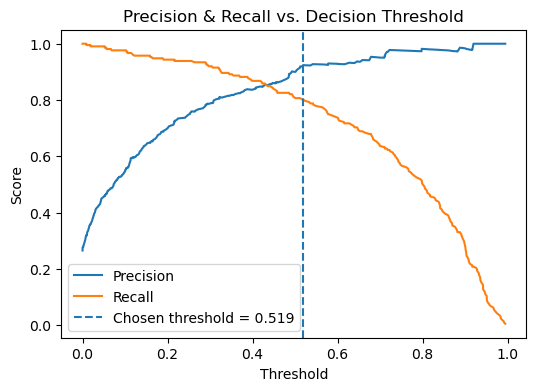

Confusion matrix at chosen threshold [[TN, FP], [FN, TP]]:
[[574  14]
 [ 42 170]]
Churn
0    588
1    212
Name: count, dtype: int64


In [22]:
# Get probabilities for Churn = 1
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

# Compute precision-recall vs. thresholds
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

# precision_recall_curve returns one extra point for prec/rec at threshold=-inf
# Align arrays for plotting threshold-based curves
thr = np.r_[thresholds[0], thresholds]  # pad to match lengths for plotting
prec_aligned = np.r_[prec[0], prec[:-1]]
rec_aligned  = np.r_[rec[0],  rec[:-1]]

# Find threshold where recall >= 0.80
target_recall = 0.80
idx = np.where(rec >= target_recall)[0][-1]
best_threshold = thresholds[idx]
best_prec = prec[idx]
best_rec  = rec[idx]

print(f"Chosen threshold for recall ≥ {target_recall:.0%}: {best_threshold:.3f}")
print(f"At this threshold: Precision={best_prec:.3f}, Recall={best_rec:.3f}")

# Plot precision and recall vs threshold
plt.figure(figsize=(6,4))
plt.plot(thr, prec_aligned, label="Precision")
plt.plot(thr, rec_aligned,  label="Recall")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen threshold = {best_threshold:.3f}")
plt.title("Precision & Recall vs. Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# Compute confusion matrix at the chosen threshold
y_pred_custom = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_custom, labels=[0,1])
print("Confusion matrix at chosen threshold [[TN, FP], [FN, TP]]:")
print(cm)

print(y_test.value_counts(normalize=False))

### Trade-Offs at Different Thresholds

This section explores how model performance changes as we vary the probability threshold used to convert churn probabilities into binary yes/no predictions. **Higher thresholds** make the model stricter: fewer members are flagged, precision increases, but more churners are missed (higher false negatives). **Lower thresholds** make the model more lenient: more members are flagged, recall increases, but many are false alarms (higher false positives). The table below shows precision, recall, confusion matrix values, and the percent of members flagged, at thresholds chosen to meet different detection targets (20%, 50%, 80%, and 100% of churners).

We find the following:

- **80% recall**: The model catches 4 out of 5 churners (recall = 80.2%) with 92.4% precision. Only 23% of members are flagged, which is a strong trade-off.
- **50% recall**: Just half the churners are flagged, but precision reaches 98% (nearly every flagged member is truly at risk).
- **100% recall**: No churners are missed, but 83% of members must be flagged, making this threshold impractical for most campaigns.

**Takeaway**: Higher recall saves more churners but increases false positives and campaign cost. The 80% recall threshold offers a good balance between coverage and precision, and may suit many real-world retention efforts.


In [23]:
# Define recall levels to target (detection targets)
recall_targets = [0.2, 0.5, 0.8, 1.0]

# Get precision-recall-threshold curve
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_test, y_test_pred_proba)

rows = []
n = len(y_test)

for r_target in recall_targets:
    # Find the highest threshold that still gives recall >= r_target
    idx = np.where(rec_curve >= r_target)[0][-1]
    thr = thr_curve[idx] if idx < len(thr_curve) else 0.0
    
    # Predictions at this threshold
    y_pred_thr = (y_test_pred_proba >= thr).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec  = recall_score(y_test, y_pred_thr, zero_division=0)
    f1   = f1_score(y_test, y_pred_thr, zero_division=0)
    flagged = tp + fp
    
    rows.append({
        "Detection Target (% churners)": f"{int(r_target*100)}%",
        "Decision Threshold": f"{thr:.3f}",
        "Precision (% of flagged who churn)": f"{prec*100:.1f}%",
        "Recall (% of churners detected)": f"{rec*100:.1f}%",
        # "F1": f"{f1:.3f}",
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "% of all members flagged": f"{flagged/n*100:.1f}%"
    })

df_threshold_summary = pd.DataFrame(rows)
df_threshold_summary

,Detection Target (% churners),Decision Threshold,Precision (% of flagged who churn),Recall (% of churners detected),TP,FP,FN,TN,% of all members flagged
0,20%,0.926,100.0%,20.3%,43,0,169,588,5.4%
1,50%,0.800,98.1%,50.0%,106,2,106,586,13.5%
2,80%,0.519,92.4%,80.2%,170,14,42,574,23.0%
3,100%,0.009,31.9%,100.0%,212,453,0,135,83.1%


## Building Churn Risk Tiers and Personas

Instead of using a single cutoff, we group members into four risk tiers based on their predicted churn probability. Each tier shows how many members fall into it, what percentage of the test set that represents, the model’s average predicted churn rate for the tier, and the actual observed churn rate in the test data. This makes it easier to plan retention actions at different levels of risk rather than treating churn as a simple yes/no decision.

Running the analysis, we find the following:

- The Very High risk tier (≥70% probability of churning) contains 17.6% of members, and almost all of them churned (95%).
- The High risk tier (50–70%) is smaller (6.1% of members) but still has a very high observed churn rate of 75.5%.
- The Medium tier (30–50%) shows roughly 42% churn, while the Low tier (<30%) has only 3% churn.

**Takeaway:** This separation shows that the model is useful for targeting: the higher the predicted risk, the more likely members are to churn in reality. One notable pattern is that in the medium, high, and very high tiers, the observed churn rate is higher than the model’s predicted average. This means the model is somewhat conservative in its probability estimates, and underestimates how risky these groups truly are.

In [24]:
# Build a  DataFrame for the test set
test_df = pd.DataFrame({"actual": y_test.reset_index(drop=True),
                        "p_churn": y_test_pred_proba})

# Define fixed-probability tiers
labels = ["Low (<30%)", "Medium (30%–50%)", "High (50%–70%)", "Very High (≥70%)"]
test_df["risk_tier"] = pd.cut(test_df["p_churn"],
                              bins=[0.0, 0.30, 0.50, 0.70, 1.01],
                              labels=labels,
                              right=False, include_lowest=True)
test_df["risk_tier"] = test_df["risk_tier"].astype(pd.CategoricalDtype(categories=labels, ordered=True))

# Summarize by tier
n = len(test_df)
tier_summary = (test_df.groupby("risk_tier", observed=False)
                .agg(members=("actual", "size"),
                     pred_churn_rate=("p_churn", "mean"),
                     obs_churn_rate=("actual", "mean"))
                    .assign(members_pct=lambda d: d["members"] / n)
                    .reset_index())

# Order columns and format for readability
tier_summary = tier_summary[["risk_tier", "members", "members_pct", "pred_churn_rate", "obs_churn_rate"]]
tier_summary.columns = ["Churn Risk Tier", "Members", "% of Members", "Predicted Churn Rate", "Observed Churn Rate"]

tier_summary["% of Members"]       = (tier_summary["% of Members"] * 100).map(lambda x: f"{x:.1f}%")
tier_summary["Predicted Churn Rate"] = (tier_summary["Predicted Churn Rate"] * 100).map(lambda x: f"{x:.1f}%")
tier_summary["Observed Churn Rate"]  = (tier_summary["Observed Churn Rate"] * 100).map(lambda x: f"{x:.1f}%")

tier_summary

,Churn Risk Tier,Members,% of Members,Predicted Churn Rate,Observed Churn Rate
0,Low (<30%),553,69.1%,6.1%,3.1%
1,Medium (30%–50%),57,7.1%,40.1%,42.1%
2,High (50%–70%),49,6.1%,60.6%,75.5%
3,Very High (≥70%),141,17.6%,86.7%,95.0%


### Building Personas by Risk Tier
Combining probability-based risk tiers with statistics about the tier groups, we can create personas around each risk tier. We present these in this section (table for the statistics appears after the next code cell).

Based on churn probability tiers, we can create four representative member profiles:

🟢 **Committed** – Low Risk (<30%)
- Long gym tenure (~5 months) and prefers 6-month contracts  
- High class engagement (~2x/month, both current and total)  
- Older than other groups (~30 years old), steady and consistent  

🟡 **Drifting** – Medium Risk (30–50%)
- Newer member (\~1.5 months) on short-term contracts (\~3 months)  
- Moderate engagement, but current month activity has dipped  
- Slightly younger (~29), may need a nudge to stay involved  

🟠 **At-Risk** – High Risk (50–70%)
- Very recent joiner (~1 month) with short contracts  
- Low engagement overall, especially this month  
- Young adult (~28), uncertain if they’re committing  

🔴 **Quitting** – Very High Risk (≥70%)
- Just joined (<1 month) and already likely to leave  
- Very low engagement and 1-month contracts  
- Youngest group (~26), not finding value or connection  


In [25]:
# Get the top 6 features based on permutation importance
persona_features = pi.head(6)['feature']

# Reset test set index and merge with risk tiers
X_test_reset = X_test.reset_index(drop=True)
persona_df = pd.concat([X_test_reset, test_df[["risk_tier", "actual"]]], axis=1)

# Compute median values per tier for selected features
persona_summary = persona_df.groupby("risk_tier", observed=False)[persona_features].median()

# Pull in % of members and churn rate from original tier summary
add_cols = tier_summary.set_index("Churn Risk Tier")[["% of Members", "Observed Churn Rate"]]

persona_summary = persona_summary.merge(add_cols, left_index=True, right_index=True)
persona_summary = persona_summary.reset_index().rename(columns={"risk_tier": "Churn Risk Tier"})

# Reorder columns so "Churn Risk Tier" and the two metrics come first
cols_front = ["Churn Risk Tier", "% of Members", "Observed Churn Rate"]
persona_summary = persona_summary[cols_front + [col for col in persona_summary.columns if col not in cols_front]]

persona_summary = persona_summary.round(1)

# persona_summary.style.set_caption("Average Observed Churn Rate and Median Feature Values by Churn Risk Tier")
# persona_summary.style.format(precision=1).set_caption("Average Observed Churn Rate and Median Feature Values by Churn Risk Tier")
(persona_summary.style
    .format(precision=1)
    .set_caption("Average Observed Churn Rate and Median Feature Values by Churn Risk Tier")
    .set_table_styles([{"selector": "caption", "props": [("caption-side", "bottom"), ("font-size", "16px"), ("font-weight", "bold")]}]))

,Churn Risk Tier,% of Members,Observed Churn Rate,Lifetime,Avg_class_frequency_current_month,Age,Avg_class_frequency_total,Month_to_end_contract,Contract_period
0,Low (<30%),69.1%,3.1%,4.0,2.0,30.0,2.0,6.0,6.0
1,Medium (30%–50%),7.1%,42.1%,1.0,1.6,29.0,1.7,1.0,1.0
2,High (50%–70%),6.1%,75.5%,1.0,1.2,28.0,1.4,1.0,1.0
3,Very High (≥70%),17.6%,95.0%,0.0,0.9,27.0,1.4,1.0,1.0


## Business Insights and Recommendations 

(TODO)

## Making Predictions in Practice

### Using the Model for New Observations

In this section, we show an example scoring function that, given the past month's data about a gym member, outputs probability of churn for the next month, as well as the risk tier and a binary churn flag based on the 80% decision threshold discussed above.

In [26]:
def predict_churn_from_json(model_pipeline, input_json, threshold=0.519):
    """
    Accepts a dict of features.
    Returns JSON with churn probability, risk tier, and binary prediction.
    """
    # Convert JSON to DataFrame
    input_df = pd.DataFrame([input_json])

    # Predict probability
    p_churn = model_pipeline.predict_proba(input_df)[:, 1][0]

    # Determine risk tier
    bins = [0.0, 0.30, 0.50, 0.70, 1.01]
    # labels = ["Low (<30%)", "Medium (30%–50%)", "High (50%–70%)", "Very High (≥70%)"]
    labels = ["Low", "Medium", "High", "Very High"]
    risk_tier = pd.cut([p_churn], bins=bins, labels=labels, right=False)[0]

    # Apply decision threshold
    churn_prediction = int(p_churn >= threshold)

    # Return JSON-style dict
    return {
        "churn_probability": round(p_churn, 4),
        "churn_risk_tier": str(risk_tier),
        "churn_prediction": churn_prediction
    }

In [27]:
# Example use
print("Example gym member:\n")
print(X_test.iloc[0])
sample_json = X_test.iloc[0].to_dict()
print("\nModel prediction:")
predict_churn_from_json(clf_pipeline, sample_json)

Example gym member:

gender                                1.00
Near_Location                         0.00
Partner                               1.00
Promo_friends                         0.00
Phone                                 1.00
Contract_period                       1.00
Group_visits                          1.00
Age                                  29.00
Avg_additional_charges_total         21.26
Month_to_end_contract                 1.00
Lifetime                              7.00
Avg_class_frequency_total             0.50
Avg_class_frequency_current_month     0.50
Name: 1799, dtype: float64

Model prediction:


{'churn_probability': 0.1849, 'churn_risk_tier': 'Low', 'churn_prediction': 0}

### Notes on Deployment

This model can be deployed as a REST API using `FastAPI` or `Flask`. A sample endpoint could accept JSON input for a new member and return predicted churn probability, risk tier, and churn flag.

Model artifacts (preprocessing pipeline + model) can be serialized with `joblib`. For inference in production, wrap the pipeline with a function or API endpoint that includes tier assignment logic.

## Data Quality, Limitations, and Recommendations

### Data Quality and Limitations
- This dataset was downloaded from the Kaggle data science competition platform. The data discription does not explain how the data was collected, but it appears that the data may have been generated synthetically.
- User gender is not clear from the binary (0/1) column.
- Some users have`Month_to_end_contract == Contract_period` even though `Lifetime > Contract_period`, which suggests the contract fields reset when a user rejoins, while Lifetime keeps accumulating total time since first signup. We kept all three fields but avoided assuming a fixed relationship between them.

## Data Recommendations
The following are recommendations for improving and adding to the dataset, specifically around what additional data to include.
- **Keep all users in the dataset, including those who churned**. This would allow for survival analysis modeling, where we can create a model that predicts length of time till churn.
- **Keep log of restarts or renewals of contracts**. For example, if a user joined for a month and then renewed each month for 2 months, then decided to go for a 12-month contract, this is valuable information.
- **Track which classes a user has taken**.
- **Track of how long a user spent at the gym**, if the gym requires users to "sign out" when leaving.
- **Track whether user bought items at the gym**, like snacks or equipment.